In [1]:
import numpy as np
import pandas as pd


In [3]:
df=pd.read_csv("student_mark.csv")
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.isnull().sum())

  Student_ID  Math_Q  Math_H  Math_Extra  Math_Annual  Science_Q  Science_H  \
0       S001      35      40          24           48         38         43   
1       S002      38      43          24           51         41         46   
2       S003      41      46          24           54         44         49   
3       S004      44      49          24           57         47         52   
4       S005      47      52          20           59         50         55   

   Science_Extra  Science_Annual  English_Q  ...  English_Extra  \
0             24              51         33  ...             24   
1             24              54         36  ...             24   
2             24              57         39  ...             24   
3             24              60         42  ...             24   
4             20              62         45  ...             20   

   English_Annual  Social_Q  Social_H  Social_Extra  Social_Annual  \
0              46        36        41            24 

In [4]:
# Reshape wide data to long format
subjects = ["Math", "Science", "English", "Social", "Computer"]
long_df = pd.DataFrame()

for sub in subjects:
    temp = df[[
        "Student_ID",
        f"{sub}_Q",
        f"{sub}_H",
        f"{sub}_Extra",
        f"{sub}_Annual"
    ]].copy()
    
    temp.columns = [
        "Student_ID",
        "Quarterly",
        "Half_Yearly",
        "Extra_Classes",
        "Annual"
    ]
    
    temp["Subject"] = sub
    long_df = pd.concat([long_df, temp], ignore_index=True)

print(long_df.head())
print(long_df.shape)
print(long_df.isnull().sum())
print(long_df.describe())

  Student_ID  Quarterly  Half_Yearly  Extra_Classes  Annual Subject
0       S001         35           40             24      48    Math
1       S002         38           43             24      51    Math
2       S003         41           46             24      54    Math
3       S004         44           49             24      57    Math
4       S005         47           52             20      59    Math
(250, 6)
Student_ID       0
Quarterly        0
Half_Yearly      0
Extra_Classes    0
Annual           0
Subject          0
dtype: int64
        Quarterly  Half_Yearly  Extra_Classes      Annual
count  250.000000   250.000000     250.000000  250.000000
mean    58.260000    63.260000      17.120000   69.540000
std     14.737339    14.737339       5.439112   13.434371
min     30.000000    35.000000       8.000000   43.000000
25%     46.000000    51.000000      12.000000   58.000000
50%     58.000000    63.000000      16.000000   70.000000
75%     71.000000    76.000000      24.000000   81

               Quarterly  Half_Yearly  Extra_Classes    Annual
Quarterly       1.000000     1.000000      -0.961995  0.999618
Half_Yearly     1.000000     1.000000      -0.961995  0.999618
Extra_Classes  -0.961995    -0.961995       1.000000 -0.954081
Annual          0.999618     0.999618      -0.954081  1.000000


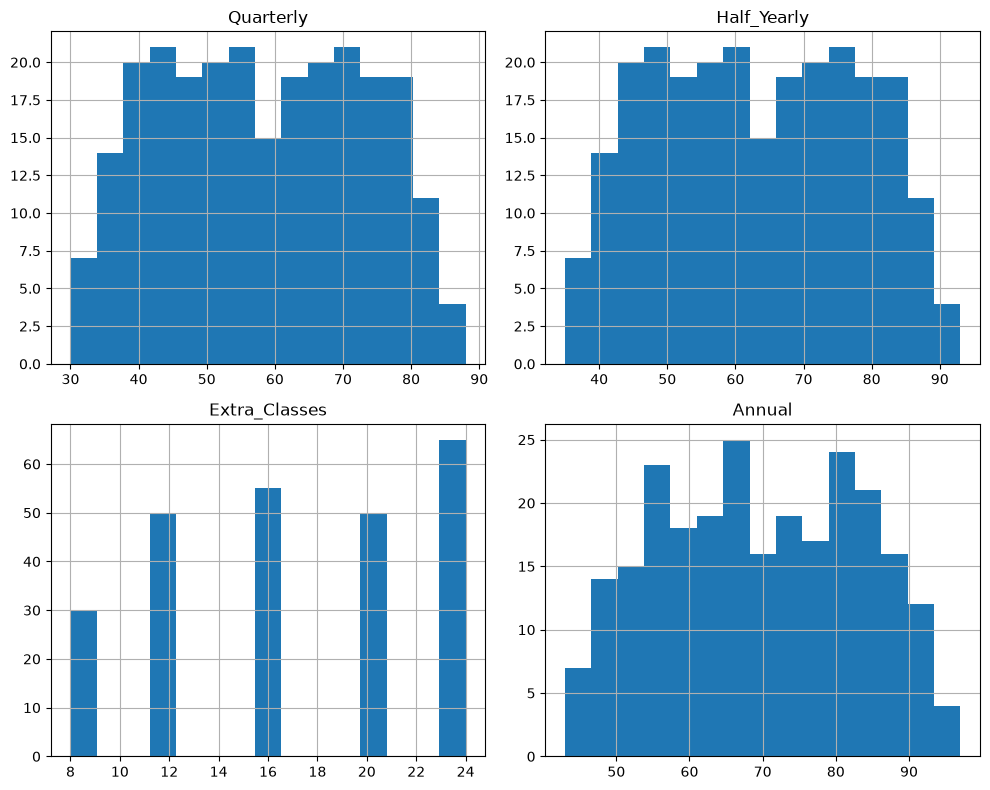

In [8]:
corr = long_df[["Quarterly", "Half_Yearly", "Extra_Classes", "Annual"]].corr()
print(corr)
import matplotlib.pyplot as plt
long_df[["Quarterly", "Half_Yearly", "Extra_Classes", "Annual"]].hist(
    figsize=(10, 8),
    bins=15
)
plt.tight_layout()
plt.show()

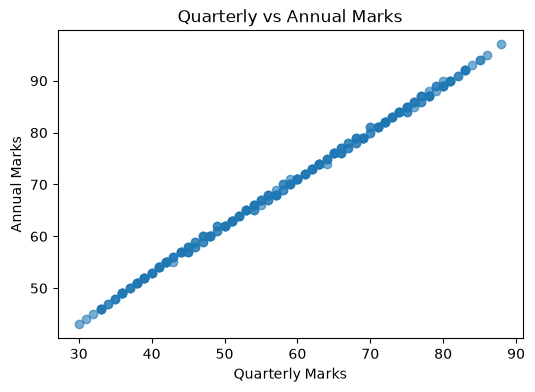

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(long_df["Quarterly"], long_df["Annual"], alpha=0.6)
plt.xlabel("Quarterly Marks")
plt.ylabel("Annual Marks")
plt.title("Quarterly vs Annual Marks")
plt.show()

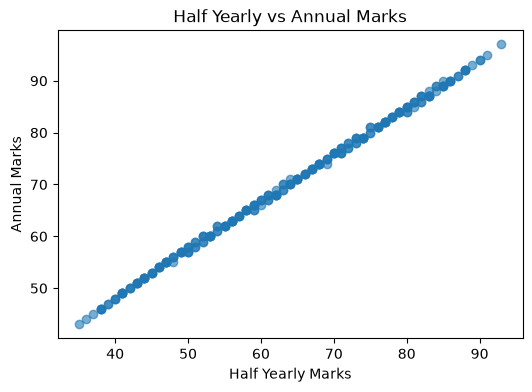

In [10]:

plt.figure(figsize=(6, 4))
plt.scatter(long_df["Half_Yearly"], long_df["Annual"], alpha=0.6)
plt.xlabel("Half Yearly Marks")
plt.ylabel("Annual Marks")
plt.title("Half Yearly vs Annual Marks")
plt.show()

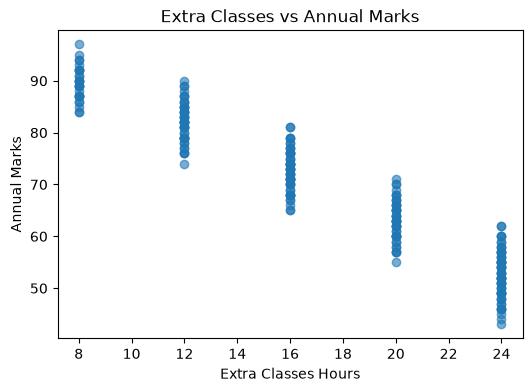

In [11]:

plt.figure(figsize=(6, 4))
plt.scatter(long_df["Extra_Classes"], long_df["Annual"], alpha=0.6)
plt.xlabel("Extra Classes Hours")
plt.ylabel("Annual Marks")
plt.title("Extra Classes vs Annual Marks")
plt.show()

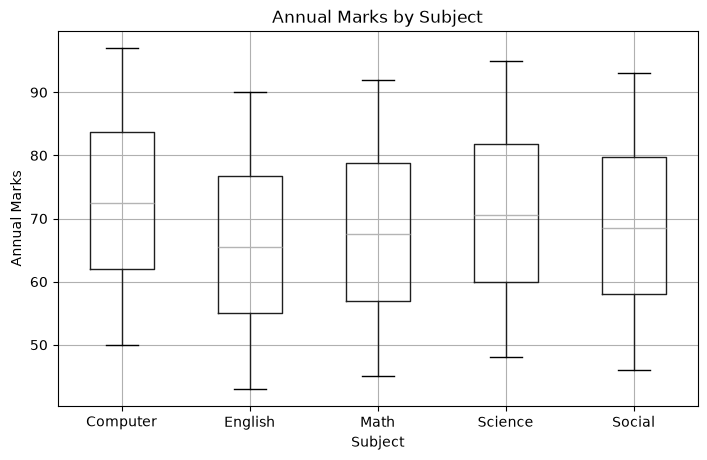

In [13]:

long_df.boxplot(column="Annual", by="Subject", figsize=(8, 5))
plt.title("Annual Marks by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("Annual Marks")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Features and target
X = long_df[["Subject", "Quarterly", "Half_Yearly", "Extra_Classes"]]
y = long_df["Annual"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Preprocessing: one-hot encode Subject, keep numeric as-is
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Subject"]),
        ("num", "passthrough", ["Quarterly", "Half_Yearly", "Extra_Classes"])
    ]
)

# Model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

MAE: 0.20
MSE: 0.08
RMSE: 0.29
R2: 1.00
CV R2 scores: [0.99899829 0.99901113 0.99758927 0.9990279  0.99613195]
Mean CV R2: 1.00


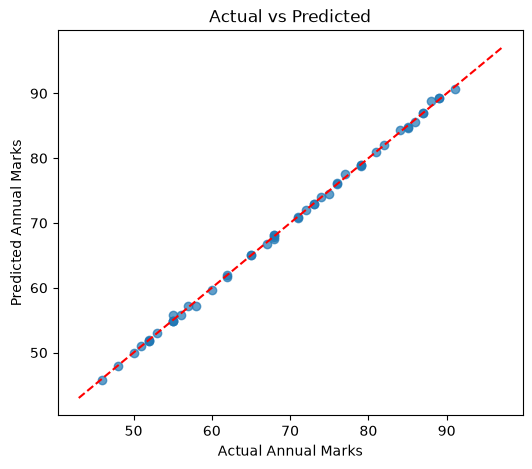

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"CV R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.2f}")

# Actual vs Predicted plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Annual Marks")
plt.ylabel("Predicted Annual Marks")
plt.title("Actual vs Predicted")
plt.show()

In [20]:
import joblib

joblib.dump(model, "student_annual_marks_model.pkl")
print("Model saved as student_annual_marks_model.pkl")

Model saved as student_annual_marks_model.pkl
